# Task 1: Purchase Prediction Model Evaluation

This notebook evaluates the trained Random Forest reorder prediction model using comprehensive metrics and visualizations.

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, auc, roc_curve
from sklearn.preprocessing import label_binarize

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / "src"))

from evaluate import (
    compute_metrics,
    evaluate_model,
    get_confusion_matrix,
    print_full_report,
)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 10

print("✓ Imports successful")

✓ Imports successful


## 2. Load Saved Model and Test Data

In [3]:
# Define paths
BASE_DIR = Path.cwd().parent
MODEL_PATH = BASE_DIR / "models" / "reorder_model.pkl"
CLASS_NAMES_PATH = BASE_DIR / "models" / "class_names.pkl"
ORDERS_PATH = BASE_DIR / "data" / "raw" / "orders.csv"
PRODUCTS_PATH = BASE_DIR / "data" / "raw" / "products.csv"

# Check if model exists
if not MODEL_PATH.exists():
    print(f"❌ Model not found at {MODEL_PATH}")
    print("Please train the model first using: python -m task1_purchase_prediction.src.model")
else:
    print(f"✓ Model found at {MODEL_PATH}")
    
# Load model
model = joblib.load(MODEL_PATH)
print(f"✓ Model loaded: {type(model).__name__}")
print(f"  - n_estimators: {model.n_estimators}")
print(f"  - max_depth: {model.max_depth}")
print(f"  - Number of features: {model.n_features_in_}")

✓ Model found at /Users/spicykiks/Desktop/kiky/Third year second semester/advanced ai/UFCFUR-15-3---Advanced-artificial-intelligence/task1_purchase_prediction/models/reorder_model.pkl
✓ Model loaded: RandomForestClassifier
  - n_estimators: 200
  - max_depth: 12
  - Number of features: 24


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 3. Run Model Evaluation

In [4]:
# Run comprehensive evaluation
metrics, y_test, y_pred, y_proba = evaluate_model(
    model_path=MODEL_PATH,
    orders_path=ORDERS_PATH,
    products_path=PRODUCTS_PATH,
    test_size=0.2,
    random_state=42,
    verbose=True,
)


MODEL EVALUATION RESULTS
Test samples: 497
Number of classes: 12

Metrics Summary:
--------------------------------------------------------------------------------
ACCURACY...................... 0.0885
PRECISION..................... 0.0906
RECALL........................ 0.0885
F1............................ 0.0868
ROC_AUC....................... 0.5317

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Apples     0.0889    0.0755    0.0816        53
       Bread     0.1250    0.0820    0.0990        61
     Carrots     0.0606    0.0476    0.0533        42
      Cheese     0.1111    0.1316    0.1205        38
   Croissant     0.1707    0.2692    0.2090        26
     Lettuce     0.0833    0.0909    0.0870        33
        Milk     0.1364    0.0896    0.1081        67
    Potatoes     0.0294    0.0217    0.0250        46
      Salmon     0.0345    0.0769    0.0476        13
Strawberries     0.0000    0.0000    0.0000        20
    Tomatoes     0.0833    

## 4. Metrics Summary Table

In [5]:
# Create metrics DataFrame for better visualization
metrics_df = pd.DataFrame([
    {"Metric": k.upper().replace("_", " "), "Score": v}
    for k, v in metrics.items()
    if not np.isnan(v)
])

print("\n" + "="*50)
print("EVALUATION METRICS SUMMARY")
print("="*50)
print(metrics_df.to_string(index=False))
print("="*50)

# Display as styled table
metrics_df.style.background_gradient(cmap="RdYlGn", subset=["Score"]).format({"Score": "{:.4f}"})


EVALUATION METRICS SUMMARY
   Metric    Score
 ACCURACY 0.088531
PRECISION 0.090641
   RECALL 0.088531
       F1 0.086826
  ROC AUC 0.531701


,Metric,Score
0,ACCURACY,0.0885
1,PRECISION,0.0906
2,RECALL,0.0885
3,F1,0.0868
4,ROC AUC,0.5317


## 5. Confusion Matrix Visualization

Confusion Matrix: 12 classes
Total test samples: 497


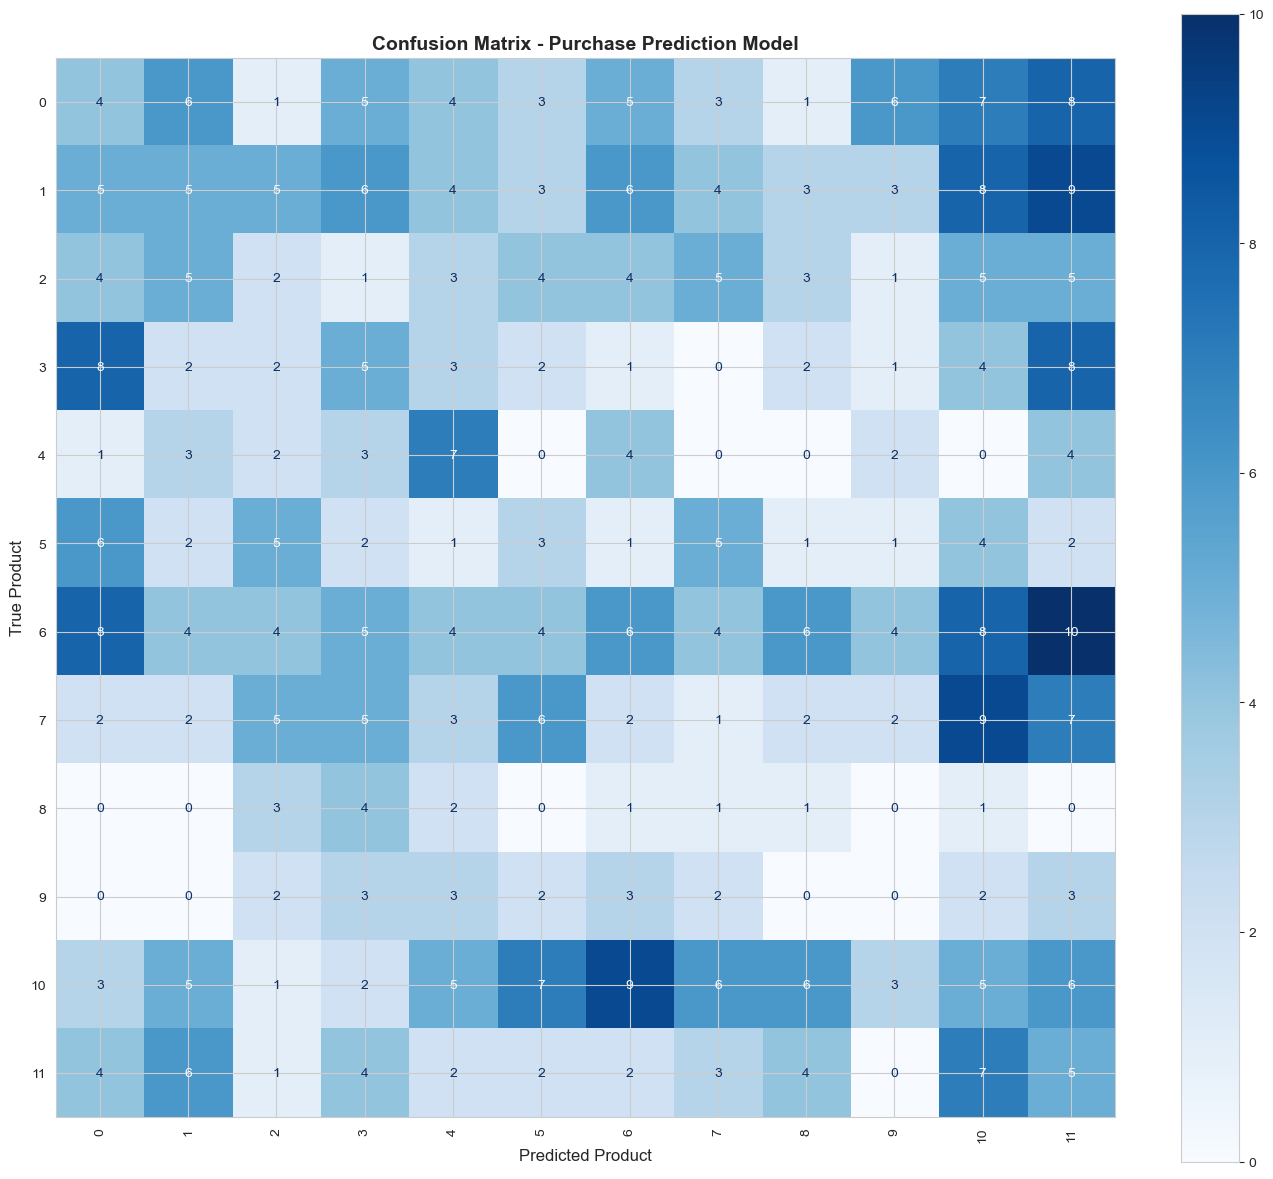


Accuracy from confusion matrix: 0.0885


In [6]:
# Get confusion matrix
cm = get_confusion_matrix(y_test, y_pred)
n_classes = len(np.unique(y_test))

print(f"Confusion Matrix: {cm.shape[0]} classes")
print(f"Total test samples: {cm.sum():.0f}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))

# Use display for cleaner visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation="vertical")

ax.set_title("Confusion Matrix - Purchase Prediction Model", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted Product", fontsize=12)
ax.set_ylabel("True Product", fontsize=12)

plt.tight_layout()
plt.show()

# Calculate accuracy from confusion matrix
cm_accuracy = np.trace(cm) / np.sum(cm)
print(f"\nAccuracy from confusion matrix: {cm_accuracy:.4f}")

## 6. Normalized Confusion Matrix

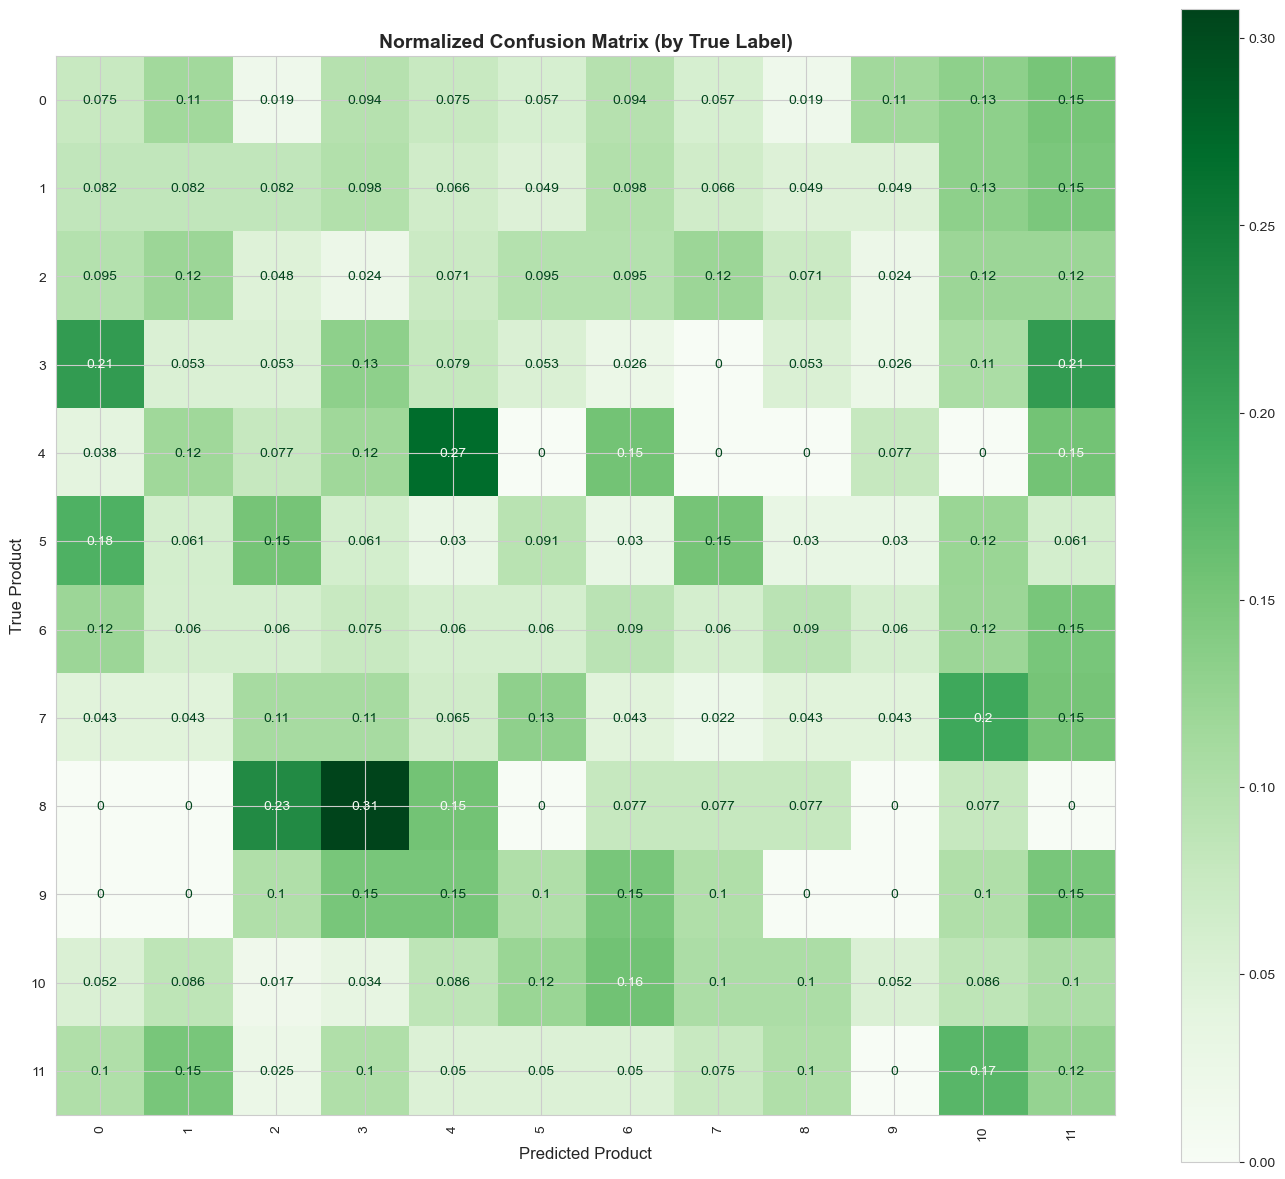

In [7]:
 # Normalize confusion matrix by true labels
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(14, 12))

disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized)
disp_norm.plot(ax=ax, cmap="Greens", colorbar=True, xticks_rotation="vertical")

ax.set_title("Normalized Confusion Matrix (by True Label)", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted Product", fontsize=12)
ax.set_ylabel("True Product", fontsize=12)

plt.tight_layout()
plt.show()

## 7. Per-Class Performance Analysis

In [8]:
from sklearn.metrics import precision_recall_fscore_support

# Calculate per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None, zero_division=0
)

# Get class names
classes = np.unique(y_test)

# Create DataFrame
class_metrics_df = pd.DataFrame({
    "Product": classes,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support,
})

# Sort by F1-score
class_metrics_df = class_metrics_df.sort_values("F1-Score", ascending=False)

print("\n" + "="*80)
print("PER-CLASS PERFORMANCE METRICS")
print("="*80)
print(class_metrics_df.to_string(index=False))
print("="*80)

# Styled display
class_metrics_df.style.background_gradient(
    cmap="RdYlGn", subset=["Precision", "Recall", "F1-Score"]
).format({
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "Support": "{:.0f}",
})


PER-CLASS PERFORMANCE METRICS
     Product  Precision   Recall  F1-Score  Support
   Croissant   0.170732 0.269231  0.208955       26
      Cheese   0.111111 0.131579  0.120482       38
        Milk   0.136364 0.089552  0.108108       67
       Bread   0.125000 0.081967  0.099010       61
      Yogurt   0.074627 0.125000  0.093458       40
     Lettuce   0.083333 0.090909  0.086957       33
    Tomatoes   0.083333 0.086207  0.084746       58
      Apples   0.088889 0.075472  0.081633       53
     Carrots   0.060606 0.047619  0.053333       42
      Salmon   0.034483 0.076923  0.047619       13
    Potatoes   0.029412 0.021739  0.025000       46
Strawberries   0.000000 0.000000  0.000000       20


,Product,Precision,Recall,F1-Score,Support
4,Croissant,0.1707,0.2692,0.2090,26
3,Cheese,0.1111,0.1316,0.1205,38
6,Milk,0.1364,0.0896,0.1081,67
1,Bread,0.1250,0.0820,0.0990,61
11,Yogurt,0.0746,0.1250,0.0935,40
5,Lettuce,0.0833,0.0909,0.0870,33
10,Tomatoes,0.0833,0.0862,0.0847,58
0,Apples,0.0889,0.0755,0.0816,53
2,Carrots,0.0606,0.0476,0.0533,42
8,Salmon,0.0345,0.0769,0.0476,13


## 8. Top/Bottom Performing Classes

In [9]:
# Top 10 performing classes
print("\n📈 TOP 10 BEST PERFORMING PRODUCTS (by F1-Score):")
print("="*80)
print(class_metrics_df.head(10).to_string(index=False))

# Bottom 10 performing classes
print("\n📉 TOP 10 WORST PERFORMING PRODUCTS (by F1-Score):")
print("="*80)
print(class_metrics_df.tail(10).to_string(index=False))


📈 TOP 10 BEST PERFORMING PRODUCTS (by F1-Score):
  Product  Precision   Recall  F1-Score  Support
Croissant   0.170732 0.269231  0.208955       26
   Cheese   0.111111 0.131579  0.120482       38
     Milk   0.136364 0.089552  0.108108       67
    Bread   0.125000 0.081967  0.099010       61
   Yogurt   0.074627 0.125000  0.093458       40
  Lettuce   0.083333 0.090909  0.086957       33
 Tomatoes   0.083333 0.086207  0.084746       58
   Apples   0.088889 0.075472  0.081633       53
  Carrots   0.060606 0.047619  0.053333       42
   Salmon   0.034483 0.076923  0.047619       13

📉 TOP 10 WORST PERFORMING PRODUCTS (by F1-Score):
     Product  Precision   Recall  F1-Score  Support
        Milk   0.136364 0.089552  0.108108       67
       Bread   0.125000 0.081967  0.099010       61
      Yogurt   0.074627 0.125000  0.093458       40
     Lettuce   0.083333 0.090909  0.086957       33
    Tomatoes   0.083333 0.086207  0.084746       58
      Apples   0.088889 0.075472  0.081633      

## 9. Metrics Distribution Visualization

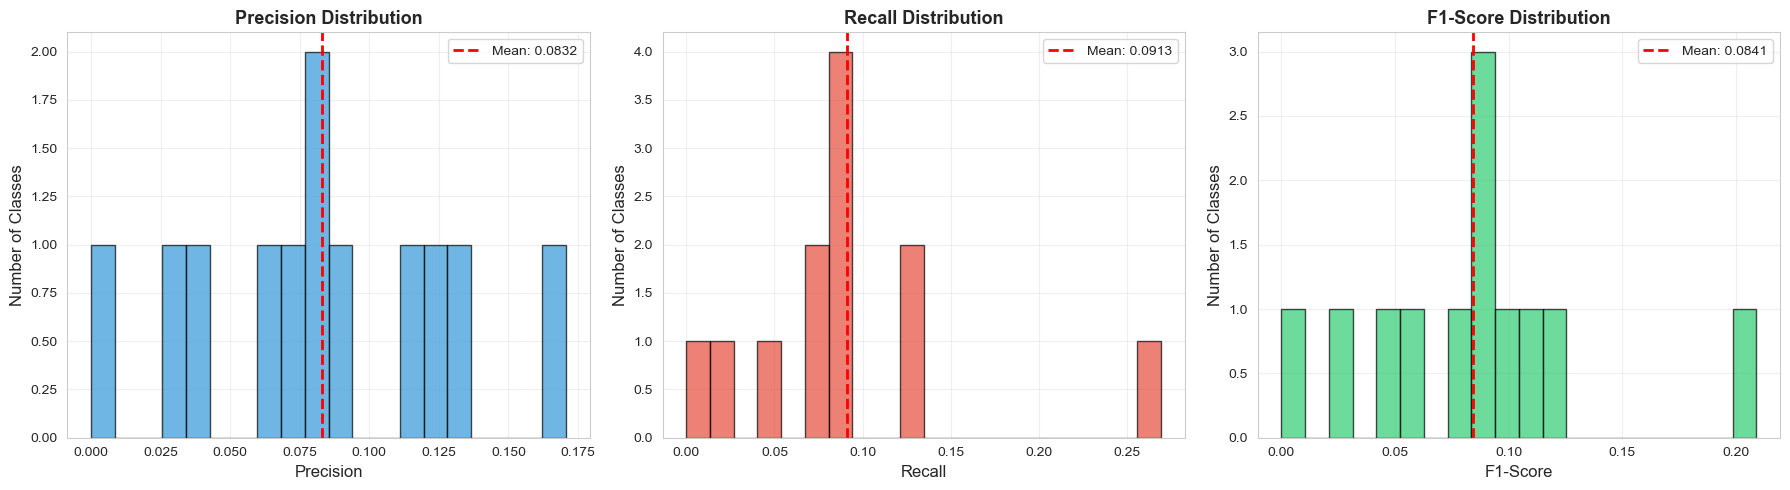

In [10]:
# Plot distribution of metrics across classes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ["Precision", "Recall", "F1-Score"]
colors = ["#3498db", "#e74c3c", "#2ecc71"]

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    ax.hist(class_metrics_df[metric], bins=20, color=color, alpha=0.7, edgecolor="black")
    ax.axvline(
        class_metrics_df[metric].mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {class_metrics_df[metric].mean():.4f}",
    )
    ax.set_xlabel(metric, fontsize=12)
    ax.set_ylabel("Number of Classes", fontsize=12)
    ax.set_title(f"{metric} Distribution", fontsize=13, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. ROC Curve (Multi-class)

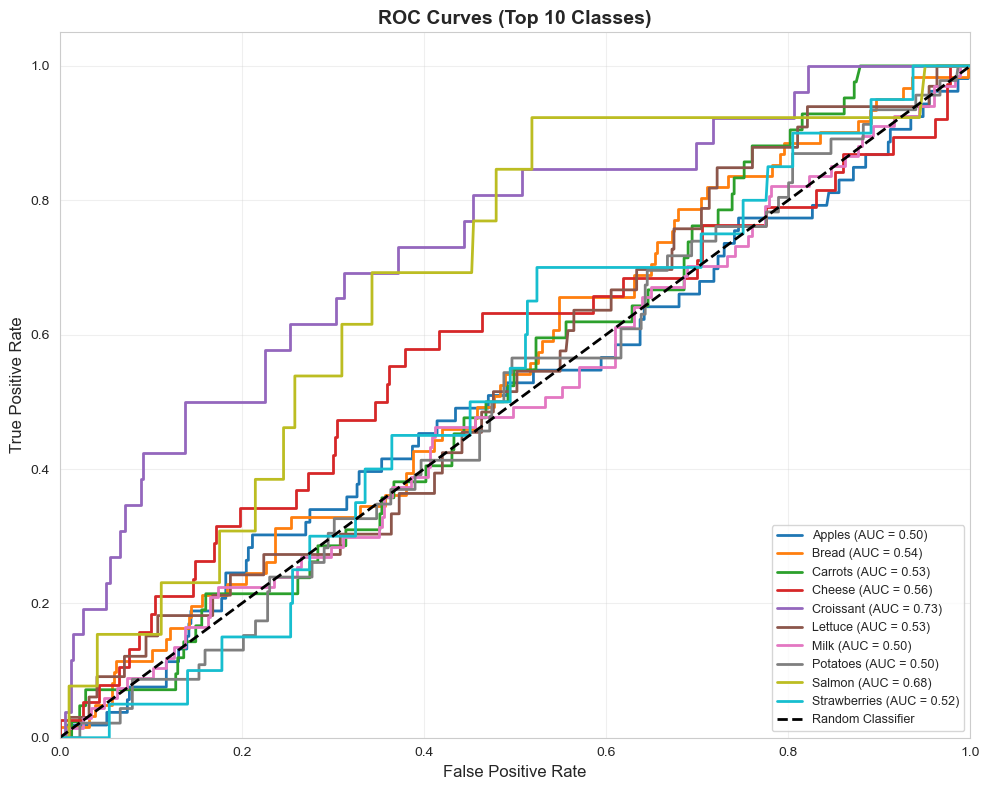


Mean ROC-AUC across top 10 classes: 0.5608


In [11]:
if y_proba is not None and len(np.unique(y_test)) > 2:
    # Multi-class ROC curve (macro-average)
    classes = np.unique(y_test)
    n_classes = len(classes)
    
    # Binarize the output
    y_test_bin = label_binarize(y_test, classes=classes)
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(min(n_classes, 10)):  # Limit to top 10 classes for clarity
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Plot ROC curves
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for i in range(min(n_classes, 10)):
        ax.plot(
            fpr[i],
            tpr[i],
            lw=2,
            label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})",
        )
    
    ax.plot([0, 1], [0, 1], "k--", lw=2, label="Random Classifier")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title("ROC Curves (Top 10 Classes)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nMean ROC-AUC across top 10 classes: {np.mean(list(roc_auc.values())):.4f}")
else:
    print("\nROC curve not plotted (binary classification or no probabilities)")

## 11. Feature Importance Analysis

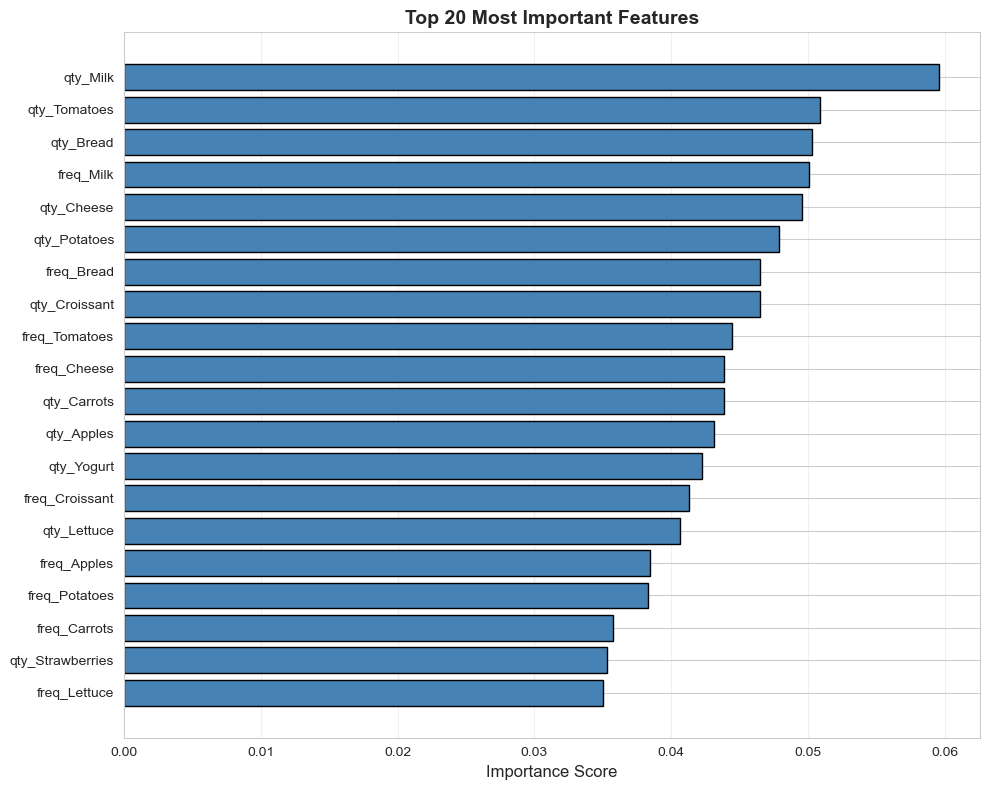


Top 20 Important Features:
         Feature  Importance
        qty_Milk    0.059612
    qty_Tomatoes    0.050869
       qty_Bread    0.050314
       freq_Milk    0.050057
      qty_Cheese    0.049602
    qty_Potatoes    0.047899
      freq_Bread    0.046538
   qty_Croissant    0.046530
   freq_Tomatoes    0.044476
     freq_Cheese    0.043861
     qty_Carrots    0.043844
      qty_Apples    0.043164
      qty_Yogurt    0.042246
  freq_Croissant    0.041293
     qty_Lettuce    0.040622
     freq_Apples    0.038482
   freq_Potatoes    0.038303
    freq_Carrots    0.035718
qty_Strawberries    0.035336
    freq_Lettuce    0.035032


In [12]:
if hasattr(model, "feature_importances_"):
    # Get feature importances
    feature_importance = model.feature_importances_
    feature_names = model.feature_names_in_
    
    # Create DataFrame
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": feature_importance,
    }).sort_values("Importance", ascending=False)
    
    # Plot top 20 features
    top_n = 20
    fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.barh(
        range(top_n),
        importance_df.head(top_n)["Importance"],
        color="steelblue",
        edgecolor="black",
    )
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(importance_df.head(top_n)["Feature"])
    ax.invert_yaxis()
    ax.set_xlabel("Importance Score", fontsize=12)
    ax.set_title(f"Top {top_n} Most Important Features", fontsize=14, fontweight="bold")
    ax.grid(alpha=0.3, axis="x")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTop {top_n} Important Features:")
    print(importance_df.head(top_n).to_string(index=False))
else:
    print("\nFeature importance not available for this model type")

## 12. Class Distribution in Test Set

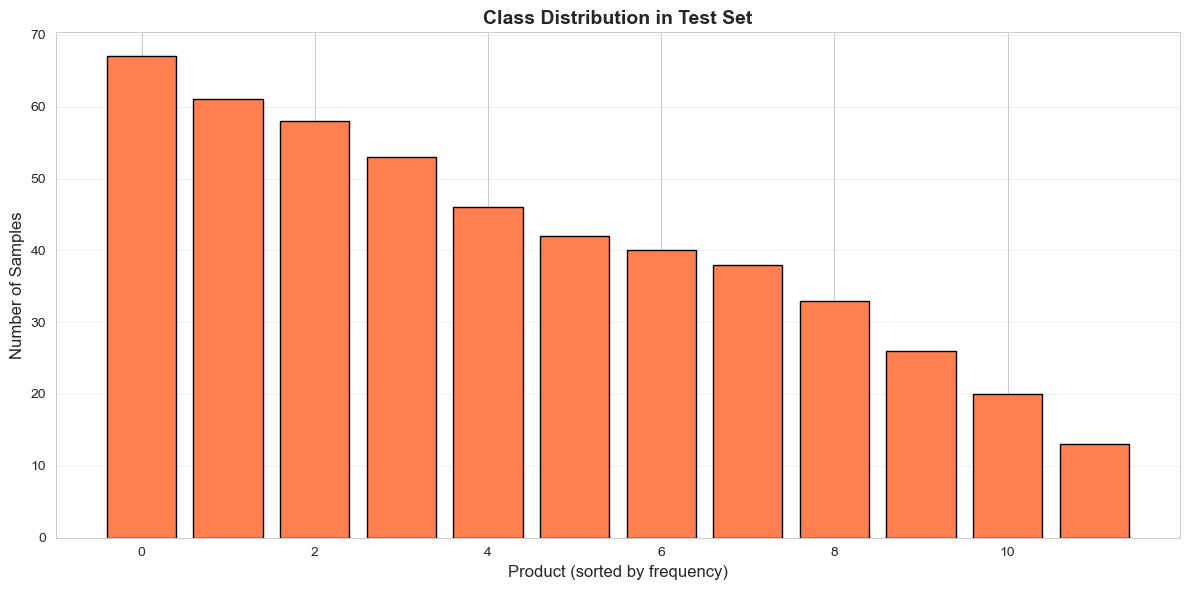


Test set statistics:
  Total samples: 497
  Number of unique classes: 12
  Most common class: Milk (67 samples)
  Least common class: Salmon (13 samples)
  Mean samples per class: 41.42
  Median samples per class: 41.00


In [13]:
# Analyze class distribution
test_distribution = pd.Series(y_test).value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(range(len(test_distribution)), test_distribution.values, color="coral", edgecolor="black")
ax.set_xlabel("Product (sorted by frequency)", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_title("Class Distribution in Test Set", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"\nTest set statistics:")
print(f"  Total samples: {len(y_test)}")
print(f"  Number of unique classes: {len(test_distribution)}")
print(f"  Most common class: {test_distribution.index[0]} ({test_distribution.values[0]} samples)")
print(f"  Least common class: {test_distribution.index[-1]} ({test_distribution.values[-1]} samples)")
print(f"  Mean samples per class: {test_distribution.mean():.2f}")
print(f"  Median samples per class: {test_distribution.median():.2f}")

## 13. Prediction Confidence Analysis

/var/folders/dm/zjk7m2zj6yb2dxr8gtn9wf600000gn/T/ipykernel_41681/597649860.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


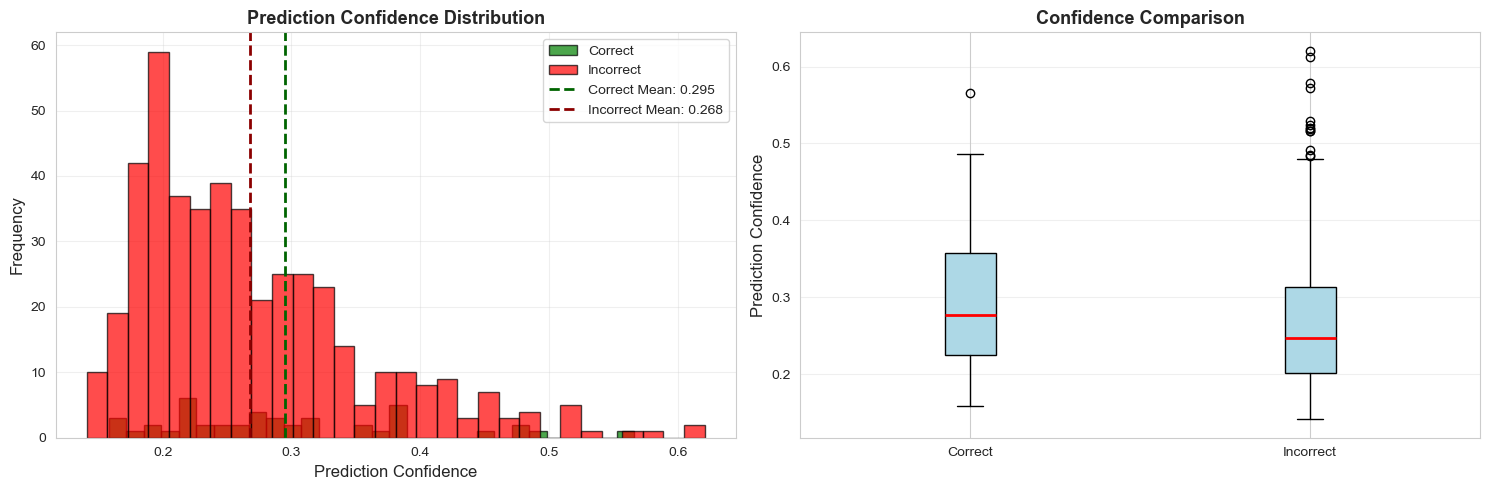


Confidence Statistics:
  Correct predictions - Mean: 0.2954, Median: 0.2769
  Incorrect predictions - Mean: 0.2680, Median: 0.2468
  High confidence (>0.8) correct: 0 / 44
  Low confidence (<0.5) incorrect: 443 / 453


In [14]:
if y_proba is not None:
    # Get maximum probability for each prediction
    max_probas = np.max(y_proba, axis=1)
    
    # Separate correct and incorrect predictions
    correct_mask = (y_test == y_pred)
    correct_probas = max_probas[correct_mask]
    incorrect_probas = max_probas[~correct_mask]
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Histogram
    axes[0].hist(
        correct_probas, bins=30, alpha=0.7, label="Correct", color="green", edgecolor="black"
    )
    axes[0].hist(
        incorrect_probas, bins=30, alpha=0.7, label="Incorrect", color="red", edgecolor="black"
    )
    axes[0].axvline(
        correct_probas.mean(), color="darkgreen", linestyle="--", linewidth=2,
        label=f"Correct Mean: {correct_probas.mean():.3f}"
    )
    axes[0].axvline(
        incorrect_probas.mean(), color="darkred", linestyle="--", linewidth=2,
        label=f"Incorrect Mean: {incorrect_probas.mean():.3f}"
    )
    axes[0].set_xlabel("Prediction Confidence", fontsize=12)
    axes[0].set_ylabel("Frequency", fontsize=12)
    axes[0].set_title("Prediction Confidence Distribution", fontsize=13, fontweight="bold")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Box plot
    axes[1].boxplot(
        [correct_probas, incorrect_probas],
        labels=["Correct", "Incorrect"],
        patch_artist=True,
        boxprops=dict(facecolor="lightblue", color="black"),
        medianprops=dict(color="red", linewidth=2),
    )
    axes[1].set_ylabel("Prediction Confidence", fontsize=12)
    axes[1].set_title("Confidence Comparison", fontsize=13, fontweight="bold")
    axes[1].grid(alpha=0.3, axis="y")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nConfidence Statistics:")
    print(f"  Correct predictions - Mean: {correct_probas.mean():.4f}, Median: {np.median(correct_probas):.4f}")
    print(f"  Incorrect predictions - Mean: {incorrect_probas.mean():.4f}, Median: {np.median(incorrect_probas):.4f}")
    print(f"  High confidence (>0.8) correct: {(correct_probas > 0.8).sum()} / {len(correct_probas)}")
    print(f"  Low confidence (<0.5) incorrect: {(incorrect_probas < 0.5).sum()} / {len(incorrect_probas)}")

## 14. Final Summary Report

In [15]:
print("\n" + "="*80)
print("FINAL EVALUATION SUMMARY")
print("="*80)
print(f"\nModel: {type(model).__name__}")
print(f"Test Set Size: {len(y_test)} samples")
print(f"Number of Classes: {len(np.unique(y_test))}")
print(f"\nOverall Performance:")
for metric, value in metrics.items():
    if not np.isnan(value):
        print(f"  {metric.upper():.<30} {value:.4f}")
print(f"\nClass-wise Performance:")
print(f"  Best performing product: {class_metrics_df.iloc[0]['Product']} (F1={class_metrics_df.iloc[0]['F1-Score']:.4f})")
print(f"  Worst performing product: {class_metrics_df.iloc[-1]['Product']} (F1={class_metrics_df.iloc[-1]['F1-Score']:.4f})")
print(f"  Mean F1-Score across products: {class_metrics_df['F1-Score'].mean():.4f}")
print(f"  Median F1-Score across products: {class_metrics_df['F1-Score'].median():.4f}")
print("\n" + "="*80)
print("✓ Evaluation completed successfully!")
print("="*80)


FINAL EVALUATION SUMMARY

Model: RandomForestClassifier
Test Set Size: 497 samples
Number of Classes: 12

Overall Performance:
  ACCURACY...................... 0.0885
  PRECISION..................... 0.0906
  RECALL........................ 0.0885
  F1............................ 0.0868
  ROC_AUC....................... 0.5317

Class-wise Performance:
  Best performing product: Croissant (F1=0.2090)
  Worst performing product: Strawberries (F1=0.0000)
  Mean F1-Score across products: 0.0841
  Median F1-Score across products: 0.0859

✓ Evaluation completed successfully!
